
# Install Required Packages




In [1]:
!pip install xgboost imbalanced-learn -q


[notice] A new release of pip is available: 25.1 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


##  Import All Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')
import joblib

## Data Upload

In [3]:
# from google.colab import files
# uploaded = files.upload()

# filename = list(uploaded.keys())[0]
# print(f"✓ Uploaded: {filename}")

# load and explore data

In [4]:
df = pd.read_csv('eff.csv')


print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())



Shape: 72629 rows, 43 columns

First 5 rows:
   Employee ID  Age  Years at Company  Monthly Income  Number of Promotions  \
0         8410   31                19            5390                     2   
1        64756   59                 4            5534                     3   
2        30257   24                10            8159                     0   
3        65791   36                 7            3989                     1   
4        65026   56                41            4821                     0   

   Distance from Home  Number of Dependents  Company Tenure (In Months)  \
0                22.0                     0                        89.0   
1                21.0                     3                        21.0   
2                11.0                     3                        74.0   
3                27.0                     2                        50.0   
4                71.0                     0                        68.0   

   Gender_Male  Job Role_Fina

In [5]:

print("Dataset Info:")
print(df.info())
print("\nDataset Summary:")
display(df.describe(include='all').T.head(10))

print("\nColumn Names:")
print(df.columns.tolist())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72629 entries, 0 to 72628
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Employee ID                          72629 non-null  int64  
 1   Age                                  72629 non-null  int64  
 2   Years at Company                     72629 non-null  int64  
 3   Monthly Income                       72629 non-null  int64  
 4   Number of Promotions                 72629 non-null  int64  
 5   Distance from Home                   72629 non-null  float64
 6   Number of Dependents                 72629 non-null  int64  
 7   Company Tenure (In Months)           72629 non-null  float64
 8   Gender_Male                          72629 non-null  int64  
 9   Job Role_Finance                     72629 non-null  int64  
 10  Job Role_Healthcare                  72629 non-null  int64  
 11  Job Role_Media

,count,mean,std,min,25%,50%,75%,max
Employee ID,72629.0,37265.866789,21500.892923,1.0,18645.0,37278.0,55905.0,74498.0
Age,72629.0,38.365653,12.049794,18.0,28.0,38.0,49.0,59.0
Years at Company,72629.0,15.437456,11.012930,1.0,7.0,13.0,22.0,47.0
Monthly Income,72629.0,7290.909031,2141.804633,1226.0,5650.0,7343.0,8867.0,13705.0
Number of Promotions,72629.0,0.831913,0.994297,0.0,0.0,1.0,2.0,4.0
Distance from Home,72629.0,49.999876,28.195123,1.0,26.0,50.0,74.0,99.0
Number of Dependents,72629.0,1.650594,1.553493,0.0,0.0,1.0,3.0,6.0
Company Tenure (In Months),72629.0,55.776095,25.582743,2.0,36.0,56.0,76.0,132.0
Gender_Male,72629.0,0.548018,0.497692,0.0,0.0,1.0,1.0,1.0
Job Role_Finance,72629.0,0.139930,0.346917,0.0,0.0,0.0,0.0,1.0



Column Names:
['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure (In Months)', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Work-Life Balance_Fair', 'Work-Life Balance_Good', 'Work-Life Balance_Poor', 'Job Satisfaction_Low', 'Job Satisfaction_Medium', 'Job Satisfaction_Very High', 'Performance Rating_Below Average', 'Performance Rating_High', 'Performance Rating_Low', 'Overtime_Yes', 'Education Level_Bachelorâ€™s Degree', 'Education Level_High School', 'Education Level_Masterâ€™s Degree', 'Education Level_PhD', 'Marital Status_Married', 'Marital Status_Single', 'Job Level_Mid', 'Job Level_Senior', 'Company Size_Medium', 'Company Size_Small', 'Remote Work_Yes', 'Leadership Opportunities_Yes', 'Innovation Opportunities_Yes', 'Company Reputation_Fair', 'Company Reputation_Good', 'Company Reputation_Poor', 'Employee Recognition_Low', 'Emplo

# data  preparation


In [6]:

if 'Attrition_Stayed' not in df.columns:
    raise ValueError(" Target column 'Attrition_Stayed' not found!")


if 'Employee ID' in df.columns:
    df = df.drop('Employee ID', axis=1)


X = df.drop('Attrition_Stayed', axis=1)
y = df['Attrition_Stayed'
]
print("Features and target separated.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target separated.
X shape: (72629, 41)
y shape: (72629,)


#train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    )

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))



Training set shape: (58103, 41)
Testing set shape: (14526, 41)
Training target distribution:
Attrition_Stayed
1    0.522365
0    0.477635
Name: proportion, dtype: float64


#Apply smote

In [8]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:" , y_train.value_counts())
print("\nAfter SMOTE:",y_train_res.value_counts())


Before SMOTE: Attrition_Stayed
1    30351
0    27752
Name: count, dtype: int64

After SMOTE: Attrition_Stayed
0    30351
1    30351
Name: count, dtype: int64


# models configuration

In [9]:
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Work-Life Balance_Fair', 'Marital Status_Married',
       'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes'],
      dtype='object')


In [10]:

models_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'liblinear']
        }
}

}

#grid search for every model


In [11]:
best_models = {}

for name, mp in models_params.items():
    print(f"\n Running Grid Search for {name}...")

    grid = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )


    grid.fit(X_train[selected_features], y_train)

    print(f" Best score for {name}: {grid.best_score_:.4f}")
    print(f" Best params for {name}: {grid.best_params_}")

    best_models[name] = grid.best_estimator_



 Running Grid Search for LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
 Best score for LogisticRegression: 0.6943
 Best params for LogisticRegression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


#models evaluation

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

evaluation = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)


    evaluation.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    })

eval_df = pd.DataFrame(evaluation).sort_values(by='F1', ascending=False)
print("\n Model Comparison:")
display(eval_df)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Age
- Company Reputation_Fair
- Company Reputation_Good
- Company Reputation_Poor
- Company Size_Medium
- ...


#confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"Model: {name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")
    print("-" * 50)


Model: RandomForest
Confusion Matrix:
[[2590 4348]
 [ 665 6923]]
True Negatives: 2590, False Positives: 4348, False Negatives: 665, True Positives: 6923
--------------------------------------------------
Model: GradientBoosting
Confusion Matrix:
[[2194 4744]
 [ 573 7015]]
True Negatives: 2194, False Positives: 4744, False Negatives: 573, True Positives: 7015
--------------------------------------------------
Model: XGBoost
Confusion Matrix:
[[1189 5749]
 [ 507 7081]]
True Negatives: 1189, False Positives: 5749, False Negatives: 507, True Positives: 7081
--------------------------------------------------
Model: LogisticRegression
Confusion Matrix:
[[   0 6938]
 [   0 7588]]
True Negatives: 0, False Positives: 6938, False Negatives: 0, True Positives: 7588
--------------------------------------------------
Model: DecisionTree
Confusion Matrix:
[[4436 2502]
 [1972 5616]]
True Negatives: 4436, False Positives: 2502, False Negatives: 1972, True Positives: 5616
------------------------------

#confusion matrix visualization

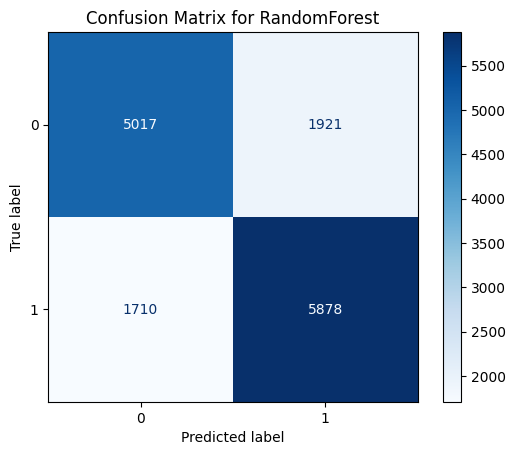

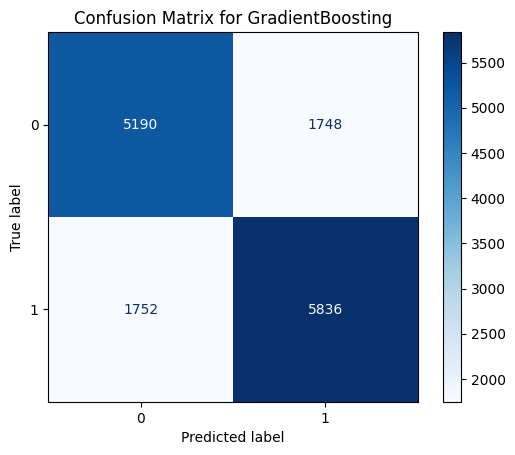

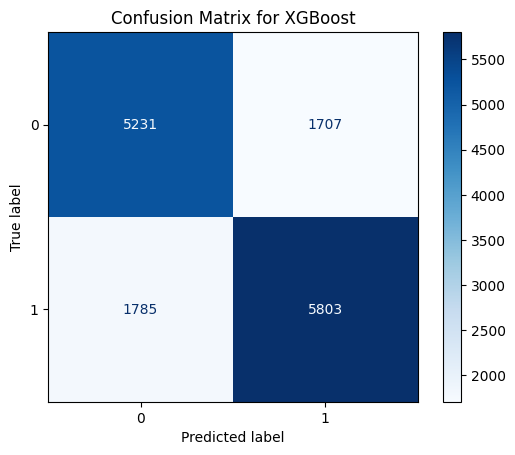

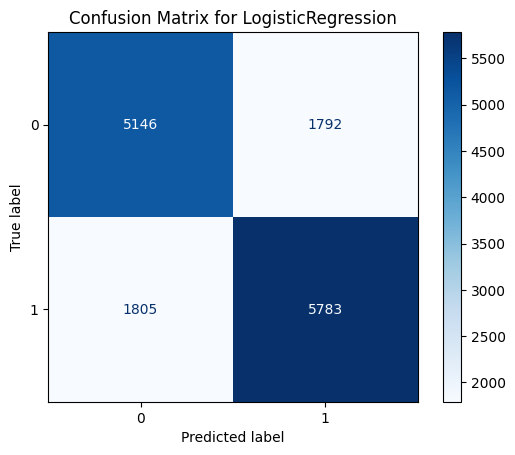

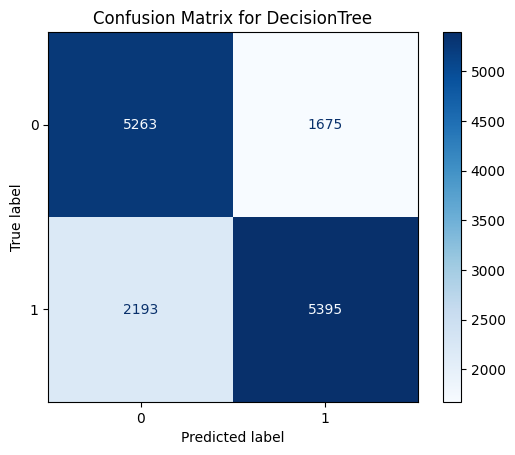

In [ ]:

eval_df = pd.DataFrame(evaluation)
eval_df


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()


#Buliding stacking model

In [ ]:
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('gb', best_models['GradientBoosting']),
        ('xgb', best_models['XGBoost']),
        ('lr', best_models['LogisticRegression']),
        ('dt', best_models['DecisionTree']),
        ('knn', best_models['KNN'])

    ],

    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)


stacking_model.fit(X_train, y_train)
y_pred = stacking_model.predict(X_test)

print("\n Final Stacking Model Accuracy:", accuracy_score(y_test, y_pred))


 Final Stacking Model Accuracy: 0.7598099958694754


#stacking model evaluation

In [ ]:
y_pred_stack = stacking_model.predict(X_test)
y_proba_stack = stacking_model.predict_proba(X_test)[:, 1]

evaluation.append({
    'Model': 'Stacking Ensemble',
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack),
    'Recall': recall_score(y_test, y_pred_stack),
    'F1': f1_score(y_test, y_pred_stack),
    'ROC_AUC': roc_auc_score(y_test, y_proba_stack)
})



#final model comparison


In [ ]:
results_df = pd.DataFrame(evaluation).sort_values(by='F1', ascending=False).reset_index(drop=True)
print("Final Model Comparison:\n")
display(results_df)

Final Model Comparison:



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,GradientBoosting,0.759053,0.769515,0.769109,0.769312,0.852026
1,XGBoost,0.759603,0.772703,0.764760,0.768711,0.852101
2,RandomForest,0.750034,0.753686,0.774644,0.764022,0.838859
3,LogisticRegression,0.752375,0.763432,0.762124,0.762778,0.844915
4,DecisionTree,0.733719,0.763083,0.710991,0.736117,0.815876


# Feature importance for tree-based models

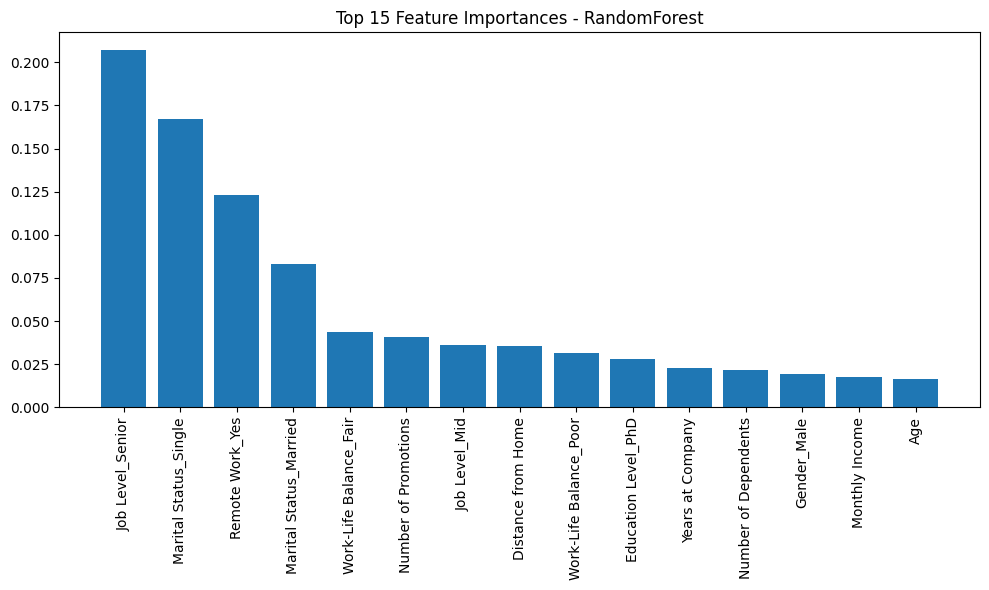

In [ ]:

import matplotlib.pyplot as plt

def plot_feature_importance(model, model_name, top_n=15):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        plt.figure(figsize=(10, 6))
        plt.title(f'Top {top_n} Feature Importances - {model_name}')
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), X.columns[indices], rotation=90)
        plt.tight_layout()
        plt.show()

# Plot for best model
best_model_name = eval_df.iloc[0]['Model']
if best_model_name != 'Stacking Ensemble':
    plot_feature_importance(best_models[best_model_name], best_model_name)

# saving the best model

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f" Best Model Based on F1 Score: {best_model_name}")

if best_model_name == 'Stacking Ensemble':
    final_model = stacking_model
else:
    final_model = best_models[best_model_name]

joblib.dump(final_model, 'final_attrition_model.pkl')
print(" Final model saved as 'final_attrition_model.pkl'")

 Best Model Based on F1 Score: Stacking Ensemble
 Final model saved as 'final_attrition_model.pkl'


In [ ]:
X_test.head()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure (In Months),Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
43656,18,3,6664,0,37.0,2,45.0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
45432,30,14,11080,0,22.0,1,72.0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
14770,42,9,6777,0,88.0,1,87.0,1,0,0,...,0,0,0,0,0,0,1,1,0,0
13733,46,31,9892,0,31.0,0,73.0,1,1,0,...,0,0,0,1,0,1,0,0,1,0
24330,30,8,5229,2,99.0,1,61.0,1,0,0,...,0,0,0,1,0,1,0,1,0,0


In [ ]:
import pandas as pd

# Create a DataFrame
data = {'A': [1, 2, 3, 4, 5],
        'B': [2, 4, 5, 4, 5],
        'C': [5, 4, 3, 2, 1]}
df = pd.DataFrame(data)

# Calculate the correlation matrix for all columns
correlation_matrix_df = df.corr()
print("Correlation Matrix (Pandas DataFrame):\n", correlation_matrix_df)

# Calculate correlation between specific columns
correlation_ab = df['A'].corr(df['B'])
print(f"Correlation between A and B (Pandas Series): {correlation_ab}")

Correlation Matrix (Pandas DataFrame):
           A         B         C
A  1.000000  0.774597 -1.000000
B  0.774597  1.000000 -0.774597
C -1.000000 -0.774597  1.000000
Correlation between A and B (Pandas Series): 0.7745966692414834


In [13]:
# import pandas as pd
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.feature_selection import SelectKBest, f_classif
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline

# # ------------------------------
# # 1) فصل الداتا
# # ------------------------------


# df = pd.read_csv('eff.csv')


# # print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
# # print(f"\nFirst 5 rows:")
# # print(df.head())
# # 

# # print("Dataset Info:")
# # print(df.info())
# # print("\nDataset Summary:")
# # display(df.describe(include='all').T.head(10))

# # print("\nColumn Names:")
# # print(df.columns.tolist())


# if 'Attrition_Stayed' not in df.columns:
#     raise ValueError(" Target column 'Attrition_Stayed' not found!")


# if 'Employee ID' in df.columns:
#     df = df.drop('Employee ID', axis=1)


# X = df.drop('Attrition_Stayed', axis=1)
# y = df['Attrition_Stayed'
# ]
# # print("Features and target separated.")
# # print("X shape:", X.shape)
# # print("y shape:", y.shape)


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42,
# stratify=y    )

# # print("Training set shape:", X_train.shape)
# # print("Testing set shape:", X_test.shape)
# # print("Training target distribution:")
# # print(y_train.value_counts(normalize=True))



# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# print("Before SMOTE:" , y_train.value_counts())
# print("\nAfter SMOTE:",y_train_res.value_counts())



# # ------------------------------
# # 2) Feature Selection → Select K Best
# # ------------------------------

# selector = SelectKBest(score_func=f_classif, k=5)
# selector.fit(X_train, y_train)

# selected_features = X_train.columns[selector.get_support()]
# print("Selected Features:", selected_features)

# # ------------------------------
# # 3) إعداد Logistic Regression + GridSearchCV
# # ------------------------------

# # لازم Scaling مع Logistic
# scaler = StandardScaler()

# logreg = LogisticRegression(max_iter=2000)

# pipeline = Pipeline([
#     ('scaler', scaler),
#     ('logreg', logreg)
# ])

# params= {
#             'logreg__C': [0.1, 1, 10],
#             'logreg__penalty': ['l2'],
#             'logreg__solver': ['lbfgs', 'liblinear']
#         }

# clf = GridSearchCV(
#     pipeline,
#     param_grid=params,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
# )

# # ------------------------------
# # 4) تدريب GridSearchCV على الــ 5 Features
# # ------------------------------

# clf.fit(X_train[selected_features], y_train)

# print("Best Params:", clf.best_params_)
# print("Best Score:", clf.best_score_)

# # ------------------------------
# # 5) تقييم الموديل على X_test بــ 5 Features
# # ------------------------------

# from sklearn.metrics import accuracy_score

# y_pred = clf.predict(X_test[selected_features])
# acc = accuracy_score(y_test, y_pred)

# print("Test Accuracy:", acc)


In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

df = pd.read_csv("eff.csv")

# drop ID columns
if 'Employee ID' in df.columns:
    df = df.drop('Employee ID', axis=1)

X = df.drop('Attrition_Stayed', axis=1)
y = df['Attrition_Stayed']

# --- split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- SMOTE ---
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# --- improved feature selection (k=10 instead of 5) ---
selector = SelectKBest(f_classif, k=5)
selector.fit(X_train_res, y_train_res)

selected_features = X_train_res.columns[selector.get_support()]
print("\nSelected Features:", selected_features)

# --- pipeline + wider grid ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=4000))
])

params = {
    'logreg__penalty': ['l1', 'l2'],
    'logreg__C': [0.01, 0.1, 1, 10, 50, 100],
    'logreg__solver': ['liblinear']   # needed for L1
}

clf = GridSearchCV(
    pipeline,
    param_grid=params,
    cv=7,
    scoring='accuracy',
    n_jobs=-1
)

clf.fit(X_train_res[selected_features], y_train_res)

print("\nBest Params:", clf.best_params_)
print("Best CV Score:", clf.best_score_)

# --- evaluate ---
y_pred = clf.predict(X_test[selected_features])
acc = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:", acc)



Selected Features: Index(['Work-Life Balance_Good', 'Marital Status_Married',
       'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes'],
      dtype='object')

Best Params: {'logreg__C': 0.01, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Best CV Score: 0.6967156995181497

Test Accuracy: 0.6838771857359218


In [15]:
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv("eff.csv")

if 'Employee ID' in df.columns:
    df = df.drop('Employee ID', axis=1)

X = df.drop('Attrition_Stayed', axis=1)
y = df['Attrition_Stayed']

# --- split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- SMOTE ---
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# --- pipeline ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),  
    ('logreg', LogisticRegression(max_iter=4000))
])

# --- search params ---
params = {
    'pca__n_components': [5, 7, 10, 15, 20],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__C': [0.1, 1, 10, 50],
    'logreg__solver': ['liblinear']
}

clf = GridSearchCV(
    pipeline,
    param_grid=params,
    cv=7,
    scoring='accuracy',
    n_jobs=-1
)

clf.fit(X_train_res, y_train_res)

print("\nBest Params:", clf.best_params_)
print("Best CV Score:", clf.best_score_)

# --- test ----
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)



Best Params: {'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear', 'pca__n_components': 20}
Best CV Score: 0.672449057647487
Test Accuracy: 0.6705218229381799


In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd
import pickle

df = pd.read_csv("eff.csv")

if 'Employee ID' in df.columns:
    df = df.drop('Employee ID', axis=1)

selected_feature=['Work-Life Balance_Good', 'Marital Status_Married' ,'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes']

X = df[selected_feature]
y = df['Attrition_Stayed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)



pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=4000))
])

params = {
    'logreg__penalty': ['l1', 'l2'],
    'logreg__C': [0.01, 0.1, 1, 10, 50, 100],
    'logreg__solver': ['liblinear']
}

clf = GridSearchCV(
    pipeline,
    param_grid=params,
    cv=7,
    scoring='accuracy',
    n_jobs=-1
)

clf.fit(X_train_res, y_train_res)

print("\nBest Params:", clf.best_params_)
print("Best CV Score:", clf.best_score_)


y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", acc)


with open("final_modell.pkl", "wb") as f:
    pickle.dump(clf, f)





Best Params: {'logreg__C': 0.01, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Best CV Score: 0.6892358640283687

Test Accuracy: 0.6877323420074349


In [17]:
# print(X_train.columns)
y_pred

array([1, 1, 0, ..., 1, 0, 1])

In [18]:
# 'Work-Life Balance_Good', 'Marital Status_Married' ,'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes

In [19]:
selected_feature=['Work-Life Balance_Good', 'Marital Status_Married' ,'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes']

In [22]:
new_data = pd.DataFrame([{
    'Work-Life Balance_Good': 1,
    'Marital Status_Married': 1,
    'Marital Status_Single': 0,
    'Job Level_Senior': 0,
    'Remote Work_Yes': 1
}])


In [23]:
with open("final_modell.pkl", "rb") as f:
    model = pickle.load(f)

prediction = model.predict(new_data)
print("Prediction:", prediction)


Prediction: [1]
